# Executive Skills Intelligence Dashboard
## High-Impact Workforce Analytics for Strategic Decision Making

**Purpose**: Generate executive-level insights from NAB's Skills Intelligence Platform for strategic workforce planning conversations.

**Target Audience**: Skills Intelligence Team, HR Leadership, Executive Committee

**Key Themes**:
- Skills concentration risk and capability resilience
- Career pathway bottlenecks and mobility opportunities
- Geographic and divisional skills distribution
- Job family connectivity and transition patterns
- Workforce deployment optimization insights

---


In [1]:
# Import libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# NAB Brand Colors
NAB_RED = '#d62c27'
NAB_BLACK = '#000000'
NAB_GRAY = '#6b7280'
EXEC_PALETTE = [NAB_RED, '#2563eb', '#059669', '#d97706', '#7c3aed', '#dc2626']

print("📊 Executive Skills Intelligence Analysis")
print("🎯 Focus: Strategic workforce insights for executive conversations")
print("📈 Output: High-impact, low-complexity visualizations")


📊 Executive Skills Intelligence Analysis
🎯 Focus: Strategic workforce insights for executive conversations
📈 Output: High-impact, low-complexity visualizations


In [2]:
# Connect to database
DB_PATH = Path("../models/2025-Q2/business_context.sqlite")

if not DB_PATH.exists():
    print(f"❌ Database not found at {DB_PATH}")
    print("Please run the CLI to generate the business context database first")
else:
    print(f"✅ Connected to database: {DB_PATH}")
    print(f"📁 Database size: {DB_PATH.stat().st_size / 1024 / 1024:.1f} MB")

conn = sqlite3.connect(DB_PATH)

# Verify tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"\n📋 Available tables: {', '.join(tables['name'].tolist())}")

# Key platform metrics for executive summary
jobs_count = pd.read_sql_query("SELECT COUNT(*) as count FROM jobs", conn).iloc[0]['count']
skills_count = pd.read_sql_query("SELECT COUNT(*) as count FROM skills", conn).iloc[0]['count']
positions_count = pd.read_sql_query("SELECT COUNT(*) as count FROM positions", conn).iloc[0]['count']
pathways_count = pd.read_sql_query("SELECT COUNT(*) as count FROM career_pathways", conn).iloc[0]['count']
job_families = pd.read_sql_query("SELECT COUNT(DISTINCT JobFamily) as count FROM jobs", conn).iloc[0]['count']
divisions = pd.read_sql_query("SELECT COUNT(DISTINCT Division) as count FROM positions", conn).iloc[0]['count']

print(f"\n🎯 PLATFORM OVERVIEW:")
print(f"   • {jobs_count:,} job profiles across {job_families} job families")
print(f"   • {skills_count:,} skills in comprehensive taxonomy")
print(f"   • {pathways_count:,} pre-computed career pathways")
print(f"   • {positions_count:,} active positions across {divisions} divisions")


✅ Connected to database: ..\models\2025-Q2\business_context.sqlite
📁 Database size: 81.0 MB

📋 Available tables: jobs, job_similarities, positions, skills, job_skills, career_pathways, schema_metadata

🎯 PLATFORM OVERVIEW:
   • 715 job profiles across 8 job families
   • 38,395 skills in comprehensive taxonomy
   • 8,580 pre-computed career pathways
   • 5,000 active positions across 6 divisions


## 1. 📊 Platform Overview & Key Metrics
### Executive Summary Statistics


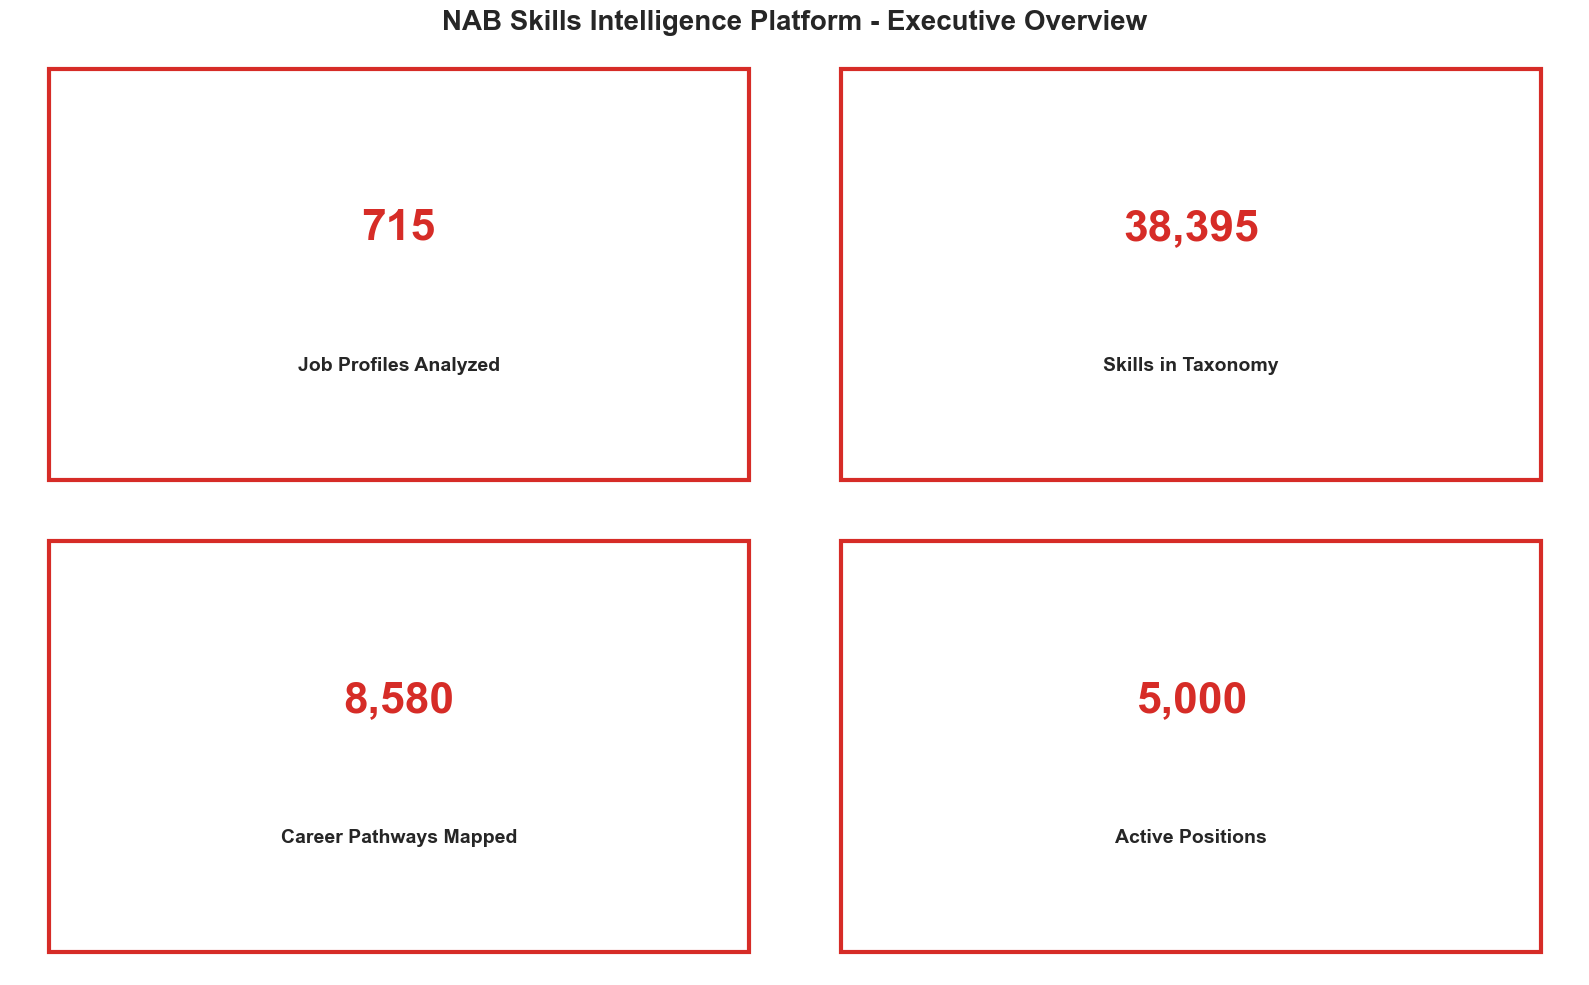

In [3]:
# Create executive summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NAB Skills Intelligence Platform - Executive Overview', fontsize=20, fontweight='bold', y=0.98)

# Key metrics cards
metrics = [
    ('Job Profiles Analyzed', jobs_count, ax1),
    ('Skills in Taxonomy', skills_count, ax2),
    ('Career Pathways Mapped', pathways_count, ax3),
    ('Active Positions', positions_count, ax4)
]

for title, value, ax in metrics:
    ax.text(0.5, 0.6, f"{value:,}", ha='center', va='center', fontsize=32, fontweight='bold', color=NAB_RED)
    ax.text(0.5, 0.3, title, ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    # Add border rectangle
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=NAB_RED, linewidth=3))

plt.tight_layout()
plt.show()


## 2. 🏢 Organizational Skills Distribution
### Where are our capabilities concentrated?


In [4]:
# Division and business unit skills distribution
division_analysis = pd.read_sql_query("""
    SELECT 
        p.Division,
        p.Business_Unit,
        COUNT(DISTINCT p.JobProfileID) as unique_roles,
        COUNT(DISTINCT p."Position Number") as total_positions,
        COUNT(DISTINCT js.Skill_ID) as unique_skills
    FROM positions p
    LEFT JOIN job_skills js ON p.JobProfileID = js.JobProfileID
    WHERE p.Division IS NOT NULL
    GROUP BY p.Division, p.Business_Unit
    ORDER BY total_positions DESC
""", conn)

# Division-level summary
division_summary = division_analysis.groupby('Division').agg({
    'unique_roles': 'sum',
    'total_positions': 'sum',
    'unique_skills': 'mean'
}).round(1).sort_values('total_positions', ascending=False)

print("🏢 ORGANIZATIONAL INSIGHTS:")
print(division_summary.to_string())
print(f"\n💡 Largest division: {division_summary.index[0]} ({division_summary.iloc[0]['total_positions']:.0f} positions)")
if len(division_summary) > 1:
    top_diverse = division_summary.sort_values('unique_roles', ascending=False)
    print(f"💡 Most diverse roles: {top_diverse.index[0]} ({top_diverse.iloc[0]['unique_roles']:.0f} unique job profiles)")


🏢 ORGANIZATIONAL INSIGHTS:
                                   unique_roles  total_positions  unique_skills
Division                                                                       
Business & Private Banking                  789              876         1143.5
Group Functions                             767              854         1117.4
Customer Banking & Wealth                   732              832         1116.8
Corporate & Institutional Banking           755              825         1107.3
NAB Ventures                                723              813         1077.5
Technology                                  710              800         1080.9

💡 Largest division: Business & Private Banking (876 positions)
💡 Most diverse roles: Business & Private Banking (789 unique job profiles)


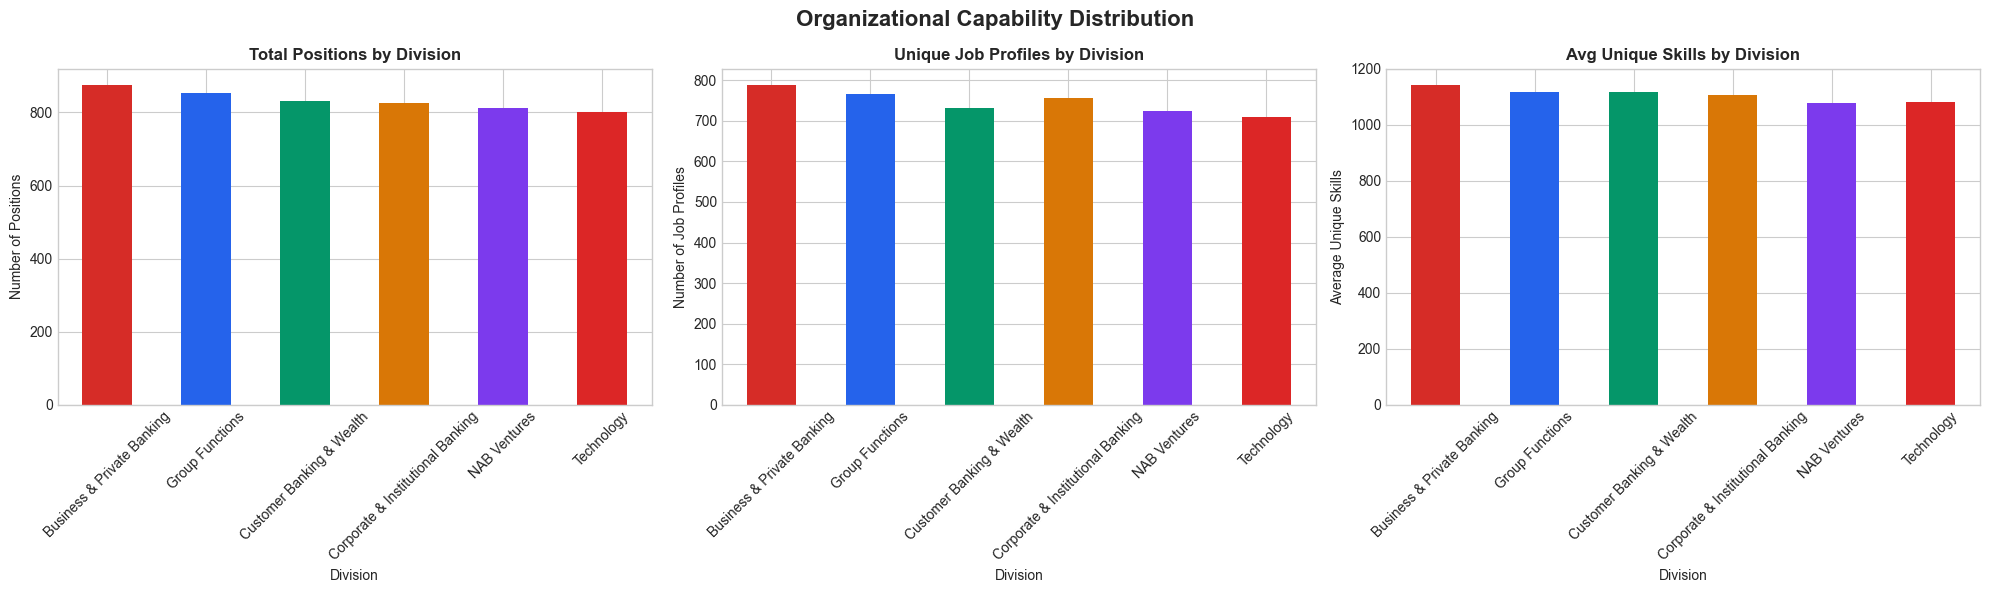

In [5]:
# Create organizational distribution visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Organizational Capability Distribution', fontsize=16, fontweight='bold')

# Positions by Division
division_summary['total_positions'].plot(kind='bar', ax=ax1, color=EXEC_PALETTE)
ax1.set_title('Total Positions by Division', fontweight='bold')
ax1.set_ylabel('Number of Positions')
ax1.tick_params(axis='x', rotation=45)

# Unique Roles by Division
division_summary['unique_roles'].plot(kind='bar', ax=ax2, color=EXEC_PALETTE)
ax2.set_title('Unique Job Profiles by Division', fontweight='bold')
ax2.set_ylabel('Number of Job Profiles')
ax2.tick_params(axis='x', rotation=45)

# Average Skills per Division
division_summary['unique_skills'].plot(kind='bar', ax=ax3, color=EXEC_PALETTE)
ax3.set_title('Avg Unique Skills by Division', fontweight='bold')
ax3.set_ylabel('Average Unique Skills')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. 🎯 Skills Concentration Risk Analysis
### Which critical skills have limited organizational resilience?


In [6]:
# Skills concentration risk analysis
skills_risk = pd.read_sql_query("""
    SELECT 
        s.Skill_Name,
        s.Category,
        s.SkillType,
        COUNT(DISTINCT js.JobProfileID) as roles_with_skill,
        COUNT(DISTINCT CASE WHEN p.JobProfileID IS NOT NULL THEN p."Position Number" END) as positions_with_skill,
        COUNT(DISTINCT p.Division) as divisions_with_skill,
        COUNT(DISTINCT p.Location) as locations_with_skill
    FROM skills s
    LEFT JOIN job_skills js ON s.Skill_ID = js.Skill_ID
    LEFT JOIN positions p ON js.JobProfileID = p.JobProfileID
    WHERE js.JobProfileID IS NOT NULL
    GROUP BY s.Skill_ID, s.Skill_Name, s.Category, s.SkillType
    HAVING roles_with_skill >= 2
    ORDER BY positions_with_skill DESC
""", conn)

# Calculate risk scores (lower positions/divisions = higher risk)
skills_risk['concentration_risk'] = 1 / (skills_risk['divisions_with_skill'] * skills_risk['positions_with_skill'])
skills_risk['risk_category'] = pd.cut(skills_risk['concentration_risk'], 
                                    bins=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Focus on high-risk critical skills
high_risk_skills = skills_risk[
    (skills_risk['risk_category'] == 'High Risk') & 
    (skills_risk['positions_with_skill'] <= 20)
].head(15)

print("🎯 SKILLS CONCENTRATION INSIGHTS:")
print(f"   • {len(skills_risk)} skills analyzed across job profiles")
print(f"   • {len(high_risk_skills)} skills identified as high concentration risk")

# Skills by category analysis
category_distribution = skills_risk.groupby('Category').agg({
    'Skill_Name': 'count',
    'positions_with_skill': 'mean',
    'divisions_with_skill': 'mean'
}).round(1).sort_values('Skill_Name', ascending=False)

print("\n📊 Skills by Category:")
print(category_distribution.head(10).to_string())


🎯 SKILLS CONCENTRATION INSIGHTS:
   • 1819 skills analyzed across job profiles
   • 15 skills identified as high concentration risk

📊 Skills by Category:
          Skill_Name  positions_with_skill  divisions_with_skill
Category                                                        
                1819                 156.4                   5.8


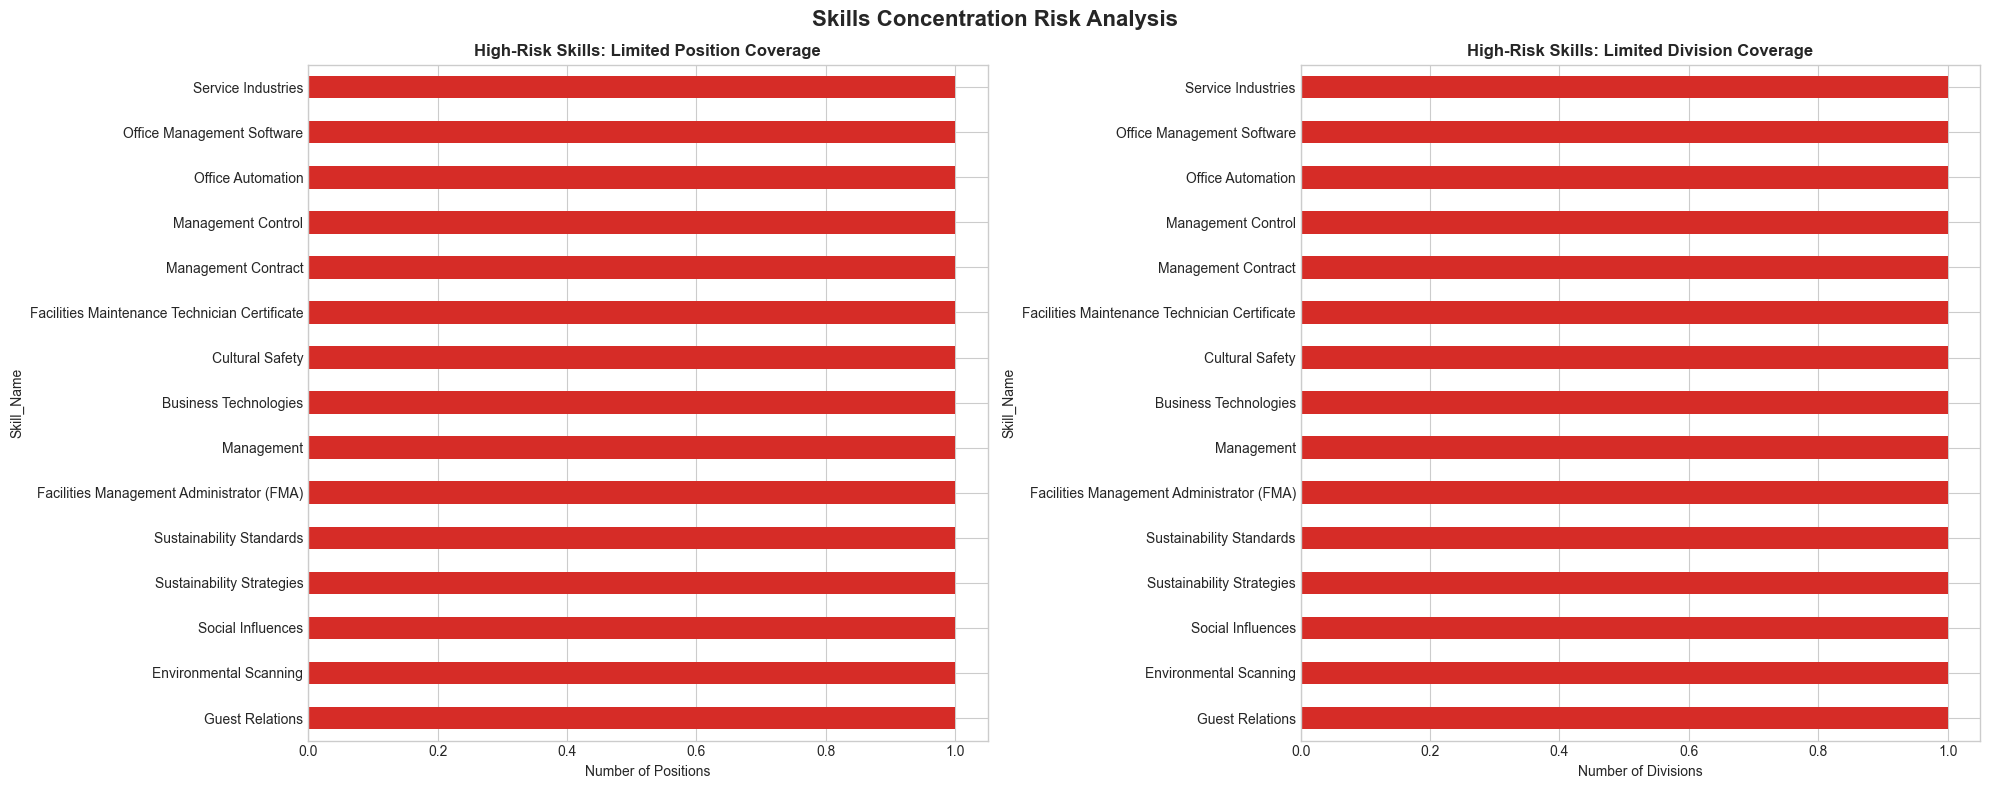

In [7]:
# Visualise skills concentration risk
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Skills Concentration Risk Analysis', fontsize=16, fontweight='bold')

# High-risk skills by positions
if len(high_risk_skills) > 0:
    high_risk_skills.set_index('Skill_Name')['positions_with_skill'].plot(
        kind='barh', ax=ax1, color=NAB_RED
    )
    ax1.set_title('High-Risk Skills: Limited Position Coverage', fontweight='bold')
    ax1.set_xlabel('Number of Positions')
    
    # Geographic distribution of high-risk skills
    high_risk_skills.set_index('Skill_Name')['divisions_with_skill'].plot(
        kind='barh', ax=ax2, color=NAB_RED
    )
    ax2.set_title('High-Risk Skills: Limited Division Coverage', fontweight='bold')
    ax2.set_xlabel('Number of Divisions')
else:
    ax1.text(0.5, 0.5, 'No high-risk skills identified\nwith current criteria', 
             ha='center', va='center', transform=ax1.transAxes)
    ax2.text(0.5, 0.5, 'Risk analysis needs\nrefinement of criteria', 
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()


## 4. 🚀 Career Pathway Intelligence
### What are the key transition patterns and bottlenecks?


In [8]:
# Career pathway analysis
pathway_analysis = pd.read_sql_query("""
    SELECT 
        j1.JobFamily as source_family,
        j2.JobFamily as target_family,
        cp.career_move_type,
        COUNT(*) as pathway_count,
        AVG(cp.similarity_score) as avg_similarity,
        AVG(cp.shared_skills_count) as avg_shared_skills
    FROM career_pathways cp
    JOIN jobs j1 ON cp.source_job_id = j1.JobProfileID
    JOIN jobs j2 ON cp.target_job_id = j2.JobProfileID
    WHERE cp.similarity_rank <= 5  -- Focus on top pathways
    GROUP BY j1.JobFamily, j2.JobFamily, cp.career_move_type
    HAVING pathway_count >= 3
    ORDER BY pathway_count DESC
""", conn)

# Most connected job families (mobility hubs)
mobility_hubs = pd.read_sql_query("""
    SELECT 
        j.JobFamily,
        COUNT(DISTINCT cp.target_job_id) as outbound_pathways,
        COUNT(DISTINCT cp.source_job_id) as inbound_pathways,
        (COUNT(DISTINCT cp.target_job_id) + COUNT(DISTINCT cp.source_job_id)) as total_connectivity
    FROM jobs j
    LEFT JOIN career_pathways cp ON j.JobProfileID = cp.source_job_id OR j.JobProfileID = cp.target_job_id
    WHERE cp.similarity_rank <= 3
    GROUP BY j.JobFamily
    ORDER BY total_connectivity DESC
    LIMIT 10
""", conn)

print("🚀 CAREER PATHWAY INSIGHTS:")
print(f"   • {len(pathway_analysis)} job family pathway combinations identified")
if len(mobility_hubs) > 0:
    print(f"   • Top mobility hub: {mobility_hubs.iloc[0]['JobFamily']} ({mobility_hubs.iloc[0]['total_connectivity']} connections)")
if len(pathway_analysis) > 0:
    print(f"   • Average pathway similarity: {pathway_analysis['avg_similarity'].mean():.2f}")
print("\n🎯 Most Connected Job Families:")
if len(mobility_hubs) > 0:
    print(mobility_hubs.head(5)[['JobFamily', 'total_connectivity']].to_string(index=False))


🚀 CAREER PATHWAY INSIGHTS:
   • 128 job family pathway combinations identified
   • Top mobility hub: Data & Analytics (618 connections)
   • Average pathway similarity: 0.78

🎯 Most Connected Job Families:
           JobFamily  total_connectivity
    Data & Analytics                 618
  Banking Operations                 617
Finance & Accounting                 616
     Human Resources                 570
Executive Leadership                 556


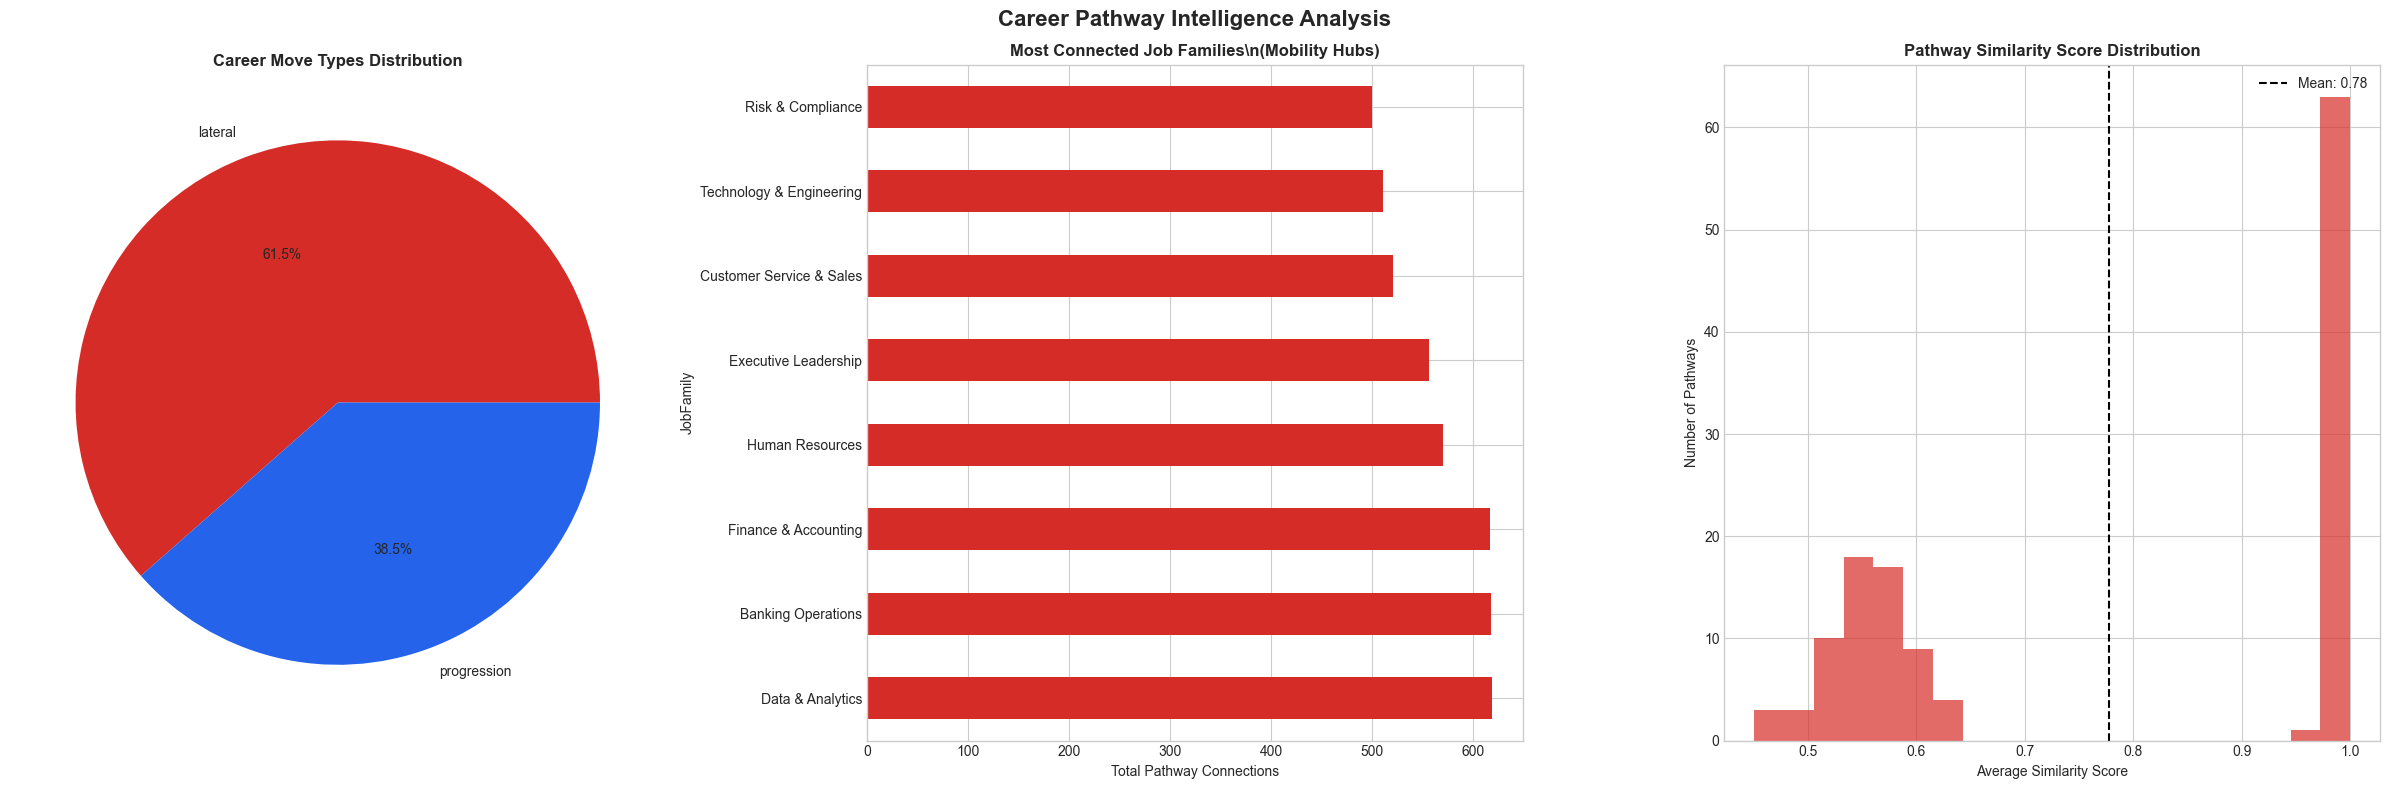

In [9]:
# Visualize career pathway intelligence
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Career Pathway Intelligence Analysis', fontsize=16, fontweight='bold')

# Career move types distribution
if len(pathway_analysis) > 0:
    move_types = pathway_analysis.groupby('career_move_type')['pathway_count'].sum()
    move_types.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=EXEC_PALETTE[:len(move_types)])
    ax1.set_title('Career Move Types Distribution', fontweight='bold')
    ax1.set_ylabel('')
else:
    ax1.text(0.5, 0.5, 'No pathway data available', ha='center', va='center', transform=ax1.transAxes)

# Mobility hubs
if len(mobility_hubs) > 0:
    mobility_hubs.set_index('JobFamily')['total_connectivity'].head(8).plot(
        kind='barh', ax=ax2, color=NAB_RED
    )
    ax2.set_title('Most Connected Job Families\\n(Mobility Hubs)', fontweight='bold')
    ax2.set_xlabel('Total Pathway Connections')
else:
    ax2.text(0.5, 0.5, 'No mobility hub data available', ha='center', va='center', transform=ax2.transAxes)

# Pathway similarity distribution
if len(pathway_analysis) > 0:
    pathway_analysis['avg_similarity'].hist(bins=20, ax=ax3, color=NAB_RED, alpha=0.7)
    ax3.set_title('Pathway Similarity Score Distribution', fontweight='bold')
    ax3.set_xlabel('Average Similarity Score')
    ax3.set_ylabel('Number of Pathways')
    ax3.axvline(pathway_analysis['avg_similarity'].mean(), color='black', linestyle='--', 
               label=f'Mean: {pathway_analysis["avg_similarity"].mean():.2f}')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'No similarity data available', ha='center', va='center', transform=ax3.transAxes)

plt.tight_layout()
plt.show()


## 5. 🌍 Geographic Skills Distribution
### Where are critical capabilities located?


In [10]:
# Geographic skills distribution
geographic_analysis = pd.read_sql_query("""
    SELECT 
        p.Location,
        p.Rg as region,
        COUNT(DISTINCT p.JobProfileID) as unique_roles,
        COUNT(DISTINCT p."Position Number") as total_positions,
        COUNT(DISTINCT js.Skill_ID) as unique_skills,
        COUNT(DISTINCT p.Division) as divisions_present
    FROM positions p
    LEFT JOIN job_skills js ON p.JobProfileID = js.JobProfileID
    WHERE p.Location IS NOT NULL AND p.Location != ''
    GROUP BY p.Location, p.Rg
    HAVING total_positions >= 10
    ORDER BY total_positions DESC
""", conn)

print("🌍 GEOGRAPHIC INSIGHTS:")
print(f"   • {len(geographic_analysis)} locations analyzed")
if len(geographic_analysis) > 0:
    print(f"   • Largest hub: {geographic_analysis.iloc[0]['Location']} ({geographic_analysis.iloc[0]['total_positions']} positions)")
    most_diverse_idx = geographic_analysis['unique_skills'].idxmax()
    print(f"   • Most diverse: {geographic_analysis.loc[most_diverse_idx, 'Location']} ({geographic_analysis.loc[most_diverse_idx, 'unique_skills']:.0f} unique skills)")
    print("\n📍 Top 5 Locations by Total Positions:")
    print(geographic_analysis[['Location', 'total_positions', 'unique_skills', 'divisions_present']].head().to_string(index=False))


🌍 GEOGRAPHIC INSIGHTS:
   • 6 locations analyzed
   • Largest hub: Perth (896 positions)
   • Most diverse: Perth (1938 unique skills)

📍 Top 5 Locations by Total Positions:
     Location  total_positions  unique_skills  divisions_present
        Perth              896           1938                  6
Brisbane City              863           1874                  6
   Parramatta              826           1848                  6
    Docklands              819           1899                  6
     Adelaide              811           1935                  6


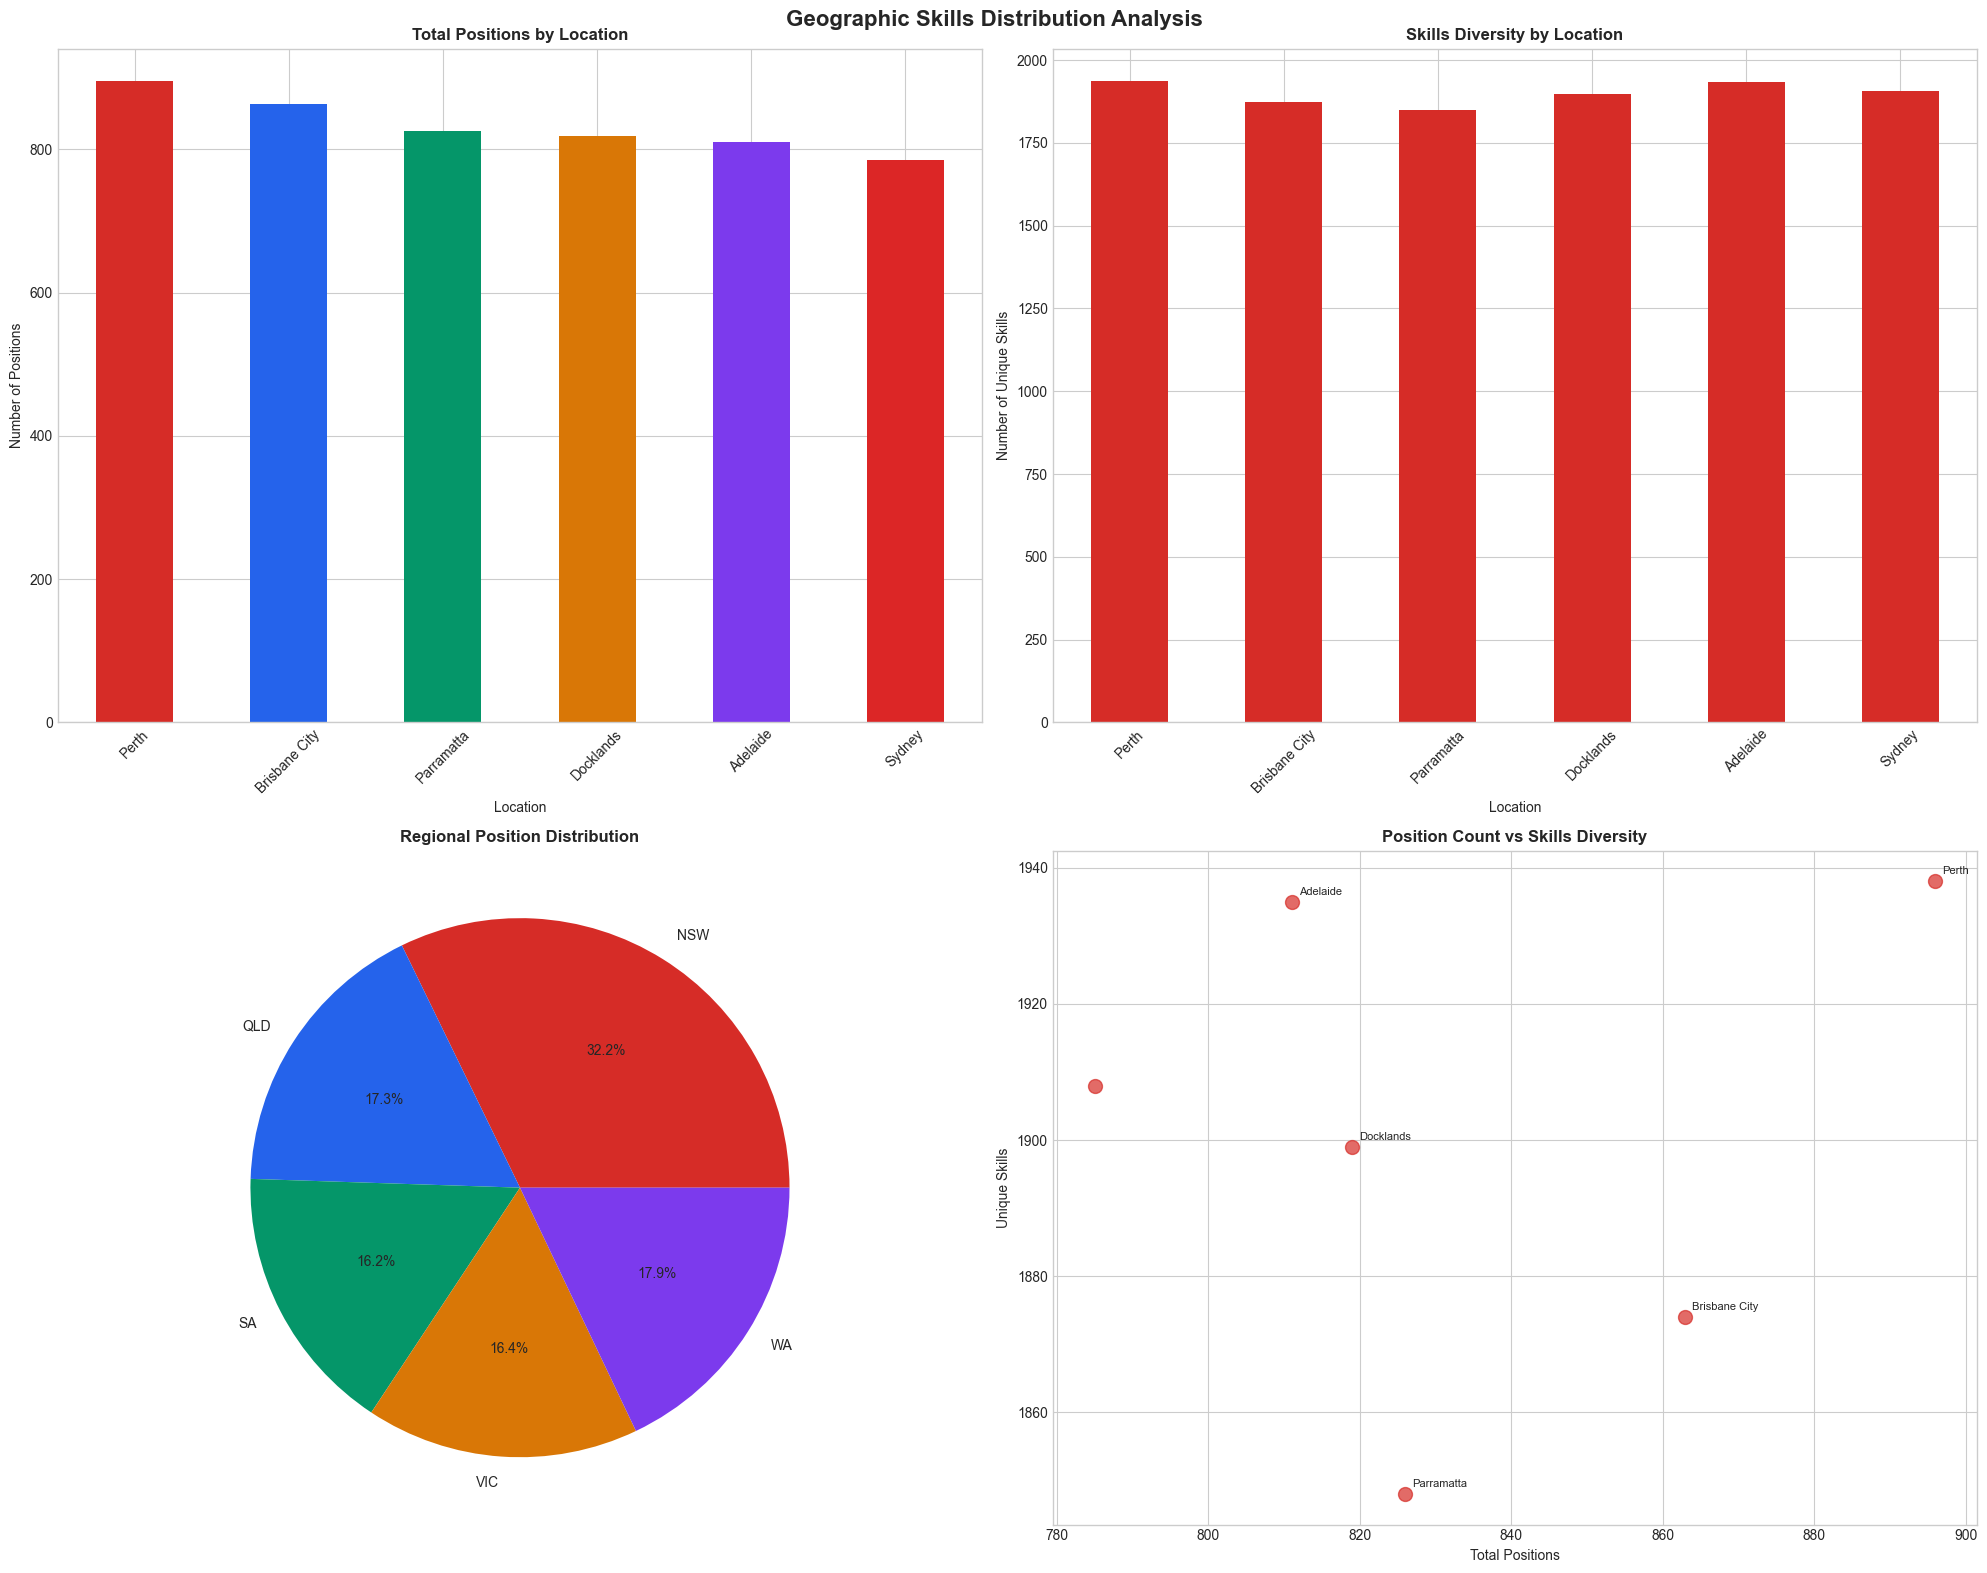

In [11]:
# Create geographic distribution visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Geographic Skills Distribution Analysis', fontsize=16, fontweight='bold')

if len(geographic_analysis) > 0:
    # Top locations by positions
    top_locations = geographic_analysis.head(10)
    top_locations.set_index('Location')['total_positions'].plot(
        kind='bar', ax=ax1, color=EXEC_PALETTE
    )
    ax1.set_title('Total Positions by Location', fontweight='bold')
    ax1.set_ylabel('Number of Positions')
    ax1.tick_params(axis='x', rotation=45)

    # Skills diversity by location
    top_locations.set_index('Location')['unique_skills'].plot(
        kind='bar', ax=ax2, color=NAB_RED
    )
    ax2.set_title('Skills Diversity by Location', fontweight='bold')
    ax2.set_ylabel('Number of Unique Skills')
    ax2.tick_params(axis='x', rotation=45)

    # Regional distribution
    if 'region' in geographic_analysis.columns and geographic_analysis['region'].notna().any():
        regional_summary = geographic_analysis.groupby('region').agg({
            'total_positions': 'sum',
            'unique_skills': 'mean'
        }).round(1)
        
        regional_summary['total_positions'].plot(kind='pie', ax=ax3, autopct='%1.1f%%', colors=EXEC_PALETTE)
        ax3.set_title('Regional Position Distribution', fontweight='bold')
        ax3.set_ylabel('')
    else:
        ax3.text(0.5, 0.5, 'No regional data available', ha='center', va='center', transform=ax3.transAxes)

    # Position vs Skills scatter plot
    top_locations.plot.scatter(x='total_positions', y='unique_skills', ax=ax4, color=NAB_RED, alpha=0.7, s=100)
    ax4.set_title('Position Count vs Skills Diversity', fontweight='bold')
    ax4.set_xlabel('Total Positions')
    ax4.set_ylabel('Unique Skills')
    
    # Add location labels for top 5
    for i, row in top_locations.head(5).iterrows():
        ax4.annotate(row['Location'], (row['total_positions'], row['unique_skills']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
else:
    for ax in [ax1, ax2, ax3, ax4]:
        ax.text(0.5, 0.5, 'No geographic data available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


## 6. 🎯 Strategic Recommendations & Dashboard Export
### Executive Action Items and Web Integration


In [12]:
# Generate strategic recommendations based on analysis
print("🎯 STRATEGIC RECOMMENDATIONS FOR EXECUTIVE TEAM")
print("=" * 60)

# Workforce resilience recommendations
if len(high_risk_skills) > 0:
    print("\n1. 🛡️ WORKFORCE RESILIENCE:")
    print(f"   • {len(high_risk_skills)} skills identified with high concentration risk")
    print("   • Recommend cross-training programs for critical skills")
    print("   • Consider geographic redistribution of specialized roles")
    print(f"   • Priority focus: {high_risk_skills.iloc[0]['Category']} skills")

# Career mobility recommendations
if len(mobility_hubs) > 0:
    print("\n2. 🚀 CAREER MOBILITY OPTIMIZATION:")
    print(f"   • {mobility_hubs.iloc[0]['JobFamily']} identified as key mobility hub")
    print(f"   • {len(pathway_analysis)} active career pathways mapped")
    print("   • Leverage mobility hubs for internal talent development")
    print("   • Create structured progression programs for connected families")

# Geographic distribution recommendations
if len(geographic_analysis) > 0:
    print("\n3. 🌍 GEOGRAPHIC OPTIMIZATION:")
    print(f"   • {geographic_analysis.iloc[0]['Location']} is the largest talent hub")
    print(f"   • {len(geographic_analysis)} locations with significant presence")
    print("   • Consider capability-based location strategies")
    print("   • Evaluate remote work opportunities for specialized skills")

# Skills taxonomy recommendations
if len(category_distribution) > 0:
    print("\n4. 🔧 SKILLS DEVELOPMENT PRIORITIES:")
    print(f"   • {category_distribution.index[0]} skills show highest organizational usage")
    print(f"   • {len(category_distribution)} skill categories actively used")
    print("   • Align learning programs with high-usage categories")
    print("   • Monitor emerging skills in top categories")

print("\n5. 📊 PLATFORM UTILIZATION:")
print(f"   • {jobs_count:,} job profiles providing comprehensive coverage")
print(f"   • {pathways_count:,} career pathways enabling strategic planning")
print("   • Platform ready for quarterly workforce planning cycles")
print("   • Recommend integration with performance management systems")

print("\n" + "=" * 60)
print("📈 NEXT STEPS: Present findings to executive committee")
print("🎯 GOAL: Data-driven workforce planning and capability development")
print("📅 REVIEW: Quarterly analysis refresh recommended")


🎯 STRATEGIC RECOMMENDATIONS FOR EXECUTIVE TEAM

1. 🛡️ WORKFORCE RESILIENCE:
   • 15 skills identified with high concentration risk
   • Recommend cross-training programs for critical skills
   • Consider geographic redistribution of specialized roles
   • Priority focus:  skills

2. 🚀 CAREER MOBILITY OPTIMIZATION:
   • Data & Analytics identified as key mobility hub
   • 128 active career pathways mapped
   • Leverage mobility hubs for internal talent development
   • Create structured progression programs for connected families

3. 🌍 GEOGRAPHIC OPTIMIZATION:
   • Perth is the largest talent hub
   • 6 locations with significant presence
   • Consider capability-based location strategies
   • Evaluate remote work opportunities for specialized skills

4. 🔧 SKILLS DEVELOPMENT PRIORITIES:
   •  skills show highest organizational usage
   • 1 skill categories actively used
   • Align learning programs with high-usage categories
   • Monitor emerging skills in top categories

5. 📊 PLATFORM 

## 7. 🔍 Skills Similarity Distribution Analysis
### Understanding Skill Relationship Patterns Across the Organization


In [13]:
# Reconnect to database for similarity analysis
conn = sqlite3.connect(DB_PATH)

# Load job similarities data for distribution analysis
print("🔍 ANALYZING SKILL SIMILARITY PATTERNS...")
print("=" * 50)

# First, let's check the table structure and get basic stats
print("🔧 DATABASE DIAGNOSTICS:")
table_info = pd.read_sql_query("PRAGMA table_info(job_similarities)", conn)
print(f"   • Table columns: {', '.join(table_info['name'].tolist())}")

# Get raw statistics directly from the table
raw_stats = pd.read_sql_query("""
    SELECT 
        COUNT(*) as total_records,
        MIN(similarity_score) as min_score,
        MAX(similarity_score) as max_score,
        AVG(similarity_score) as avg_score,
        COUNT(DISTINCT similarity_score) as unique_scores
    FROM job_similarities
""", conn)

print(f"   • Total records: {raw_stats.iloc[0]['total_records']:,}")
print(f"   • Score range: {raw_stats.iloc[0]['min_score']:.3f} - {raw_stats.iloc[0]['max_score']:.3f}")
print(f"   • Average score: {raw_stats.iloc[0]['avg_score']:.3f}")
print(f"   • Unique scores: {raw_stats.iloc[0]['unique_scores']:,}")

# Load all similarity scores for detailed analysis (not aggregated)
print(f"\n📊 LOADING SIMILARITY DATA FOR ANALYSIS...")
similarity_data = pd.read_sql_query("""
    SELECT similarity_score
    FROM job_similarities
    ORDER BY similarity_score
""", conn)

if len(similarity_data) > 0:
    print("📊 SIMILARITY DISTRIBUTION OVERVIEW:")
    print(f"   • Total job-to-job comparisons: {len(similarity_data):,}")
    print(f"   • Average similarity score: {similarity_data['similarity_score'].mean():.3f}")
    print(f"   • Median similarity score: {similarity_data['similarity_score'].median():.3f}")
    print(f"   • Highest similarity found: {similarity_data['similarity_score'].max():.3f}")
    print(f"   • Lowest similarity found: {similarity_data['similarity_score'].min():.3f}")
    print(f"   • Standard deviation: {similarity_data['similarity_score'].std():.3f}")
    
    # Calculate percentiles
    percentiles = similarity_data['similarity_score'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"\n📈 SIMILARITY PERCENTILES:")
    print(f"   • 25th percentile: {percentiles[0.25]:.3f}")
    print(f"   • 50th percentile (median): {percentiles[0.5]:.3f}")
    print(f"   • 75th percentile: {percentiles[0.75]:.3f}")
    print(f"   • 90th percentile: {percentiles[0.9]:.3f}")
    print(f"   • 95th percentile: {percentiles[0.95]:.3f}")
    print(f"   • 99th percentile: {percentiles[0.99]:.3f}")
    
    # Create aggregated data for visualization (fix the original issue)
    similarity_stats = similarity_data.copy()
    
else:
    print("⚠️ No similarity data found - check if job_similarities table exists and has data")
    similarity_stats = pd.DataFrame()


🔍 ANALYZING SKILL SIMILARITY PATTERNS...
🔧 DATABASE DIAGNOSTICS:
   • Table columns: job_from, job_to, similarity_score, skill_overlap_score, shared_skills_count, total_skills_from, total_skills_to
   • Total records: 510,510.0
   • Score range: 0.000 - 1.000
   • Average score: 0.342
   • Unique scores: 1,106.0

📊 LOADING SIMILARITY DATA FOR ANALYSIS...
📊 SIMILARITY DISTRIBUTION OVERVIEW:
   • Total job-to-job comparisons: 510,510
   • Average similarity score: 0.342
   • Median similarity score: 0.373
   • Highest similarity found: 1.000
   • Lowest similarity found: 0.000
   • Standard deviation: 0.150

📈 SIMILARITY PERCENTILES:
   • 25th percentile: 0.309
   • 50th percentile (median): 0.373
   • 75th percentile: 0.426
   • 90th percentile: 0.482
   • 95th percentile: 0.525
   • 99th percentile: 0.639


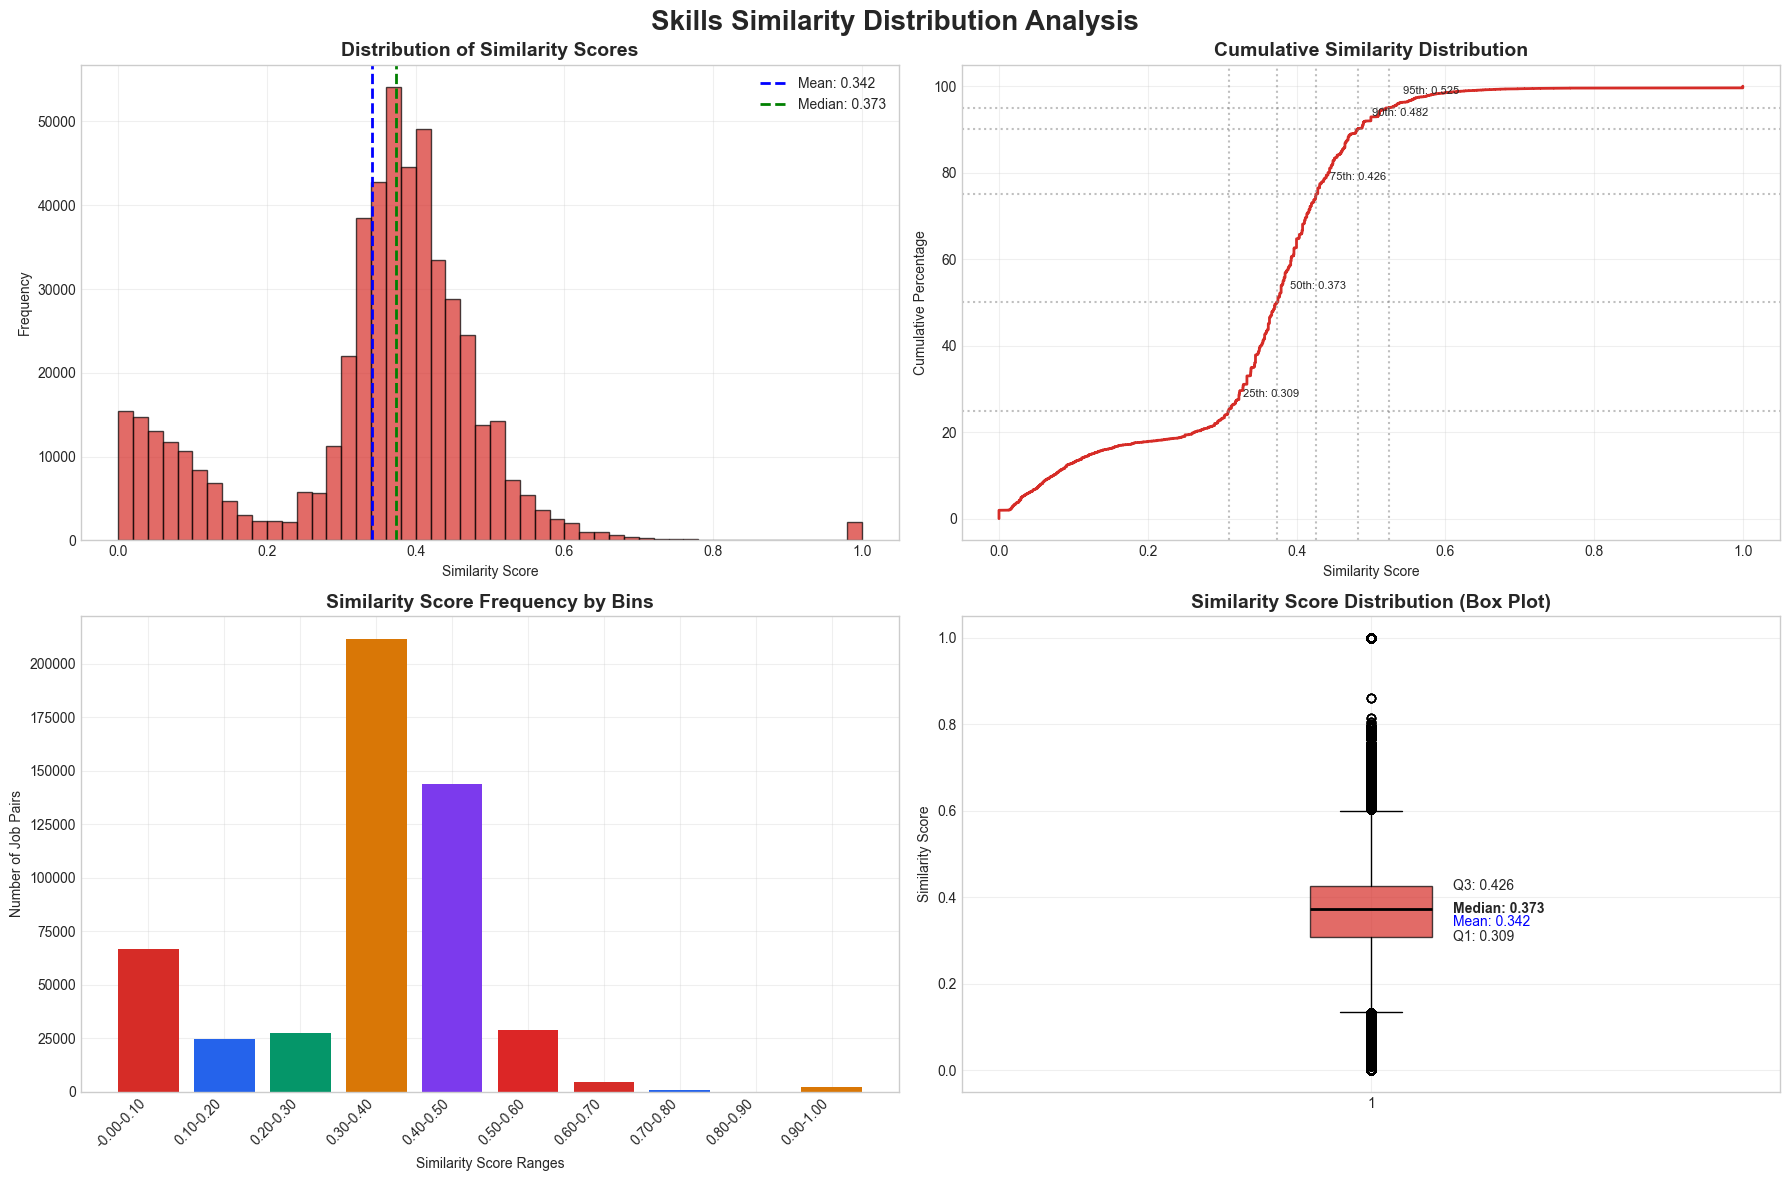

In [14]:
# Create comprehensive similarity distribution visualizations
if len(similarity_stats) > 0:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Skills Similarity Distribution Analysis', fontsize=20, fontweight='bold', y=0.98)
    
    # 1. Histogram of similarity scores
    ax1.hist(similarity_stats['similarity_score'], bins=50, color=NAB_RED, alpha=0.7, edgecolor='black')
    ax1.set_title('Distribution of Similarity Scores', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Similarity Score')
    ax1.set_ylabel('Frequency')
    ax1.grid(True, alpha=0.3)
    
    # Add mean and median lines
    mean_sim = similarity_stats['similarity_score'].mean()
    median_sim = similarity_stats['similarity_score'].median()
    ax1.axvline(mean_sim, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_sim:.3f}')
    ax1.axvline(median_sim, color='green', linestyle='--', linewidth=2, label=f'Median: {median_sim:.3f}')
    ax1.legend()
    
    # 2. Cumulative distribution
    sorted_scores = similarity_stats['similarity_score'].sort_values()
    cumulative_pct = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores) * 100
    ax2.plot(sorted_scores, cumulative_pct, color=NAB_RED, linewidth=2)
    ax2.set_title('Cumulative Similarity Distribution', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Similarity Score')
    ax2.set_ylabel('Cumulative Percentage')
    ax2.grid(True, alpha=0.3)
    
    # Add percentile markers
    for pct in [25, 50, 75, 90, 95]:
        score_value = similarity_stats['similarity_score'].quantile(pct/100)
        ax2.axhline(pct, color='gray', linestyle=':', alpha=0.5)
        ax2.axvline(score_value, color='gray', linestyle=':', alpha=0.5)
        ax2.annotate(f'{pct}th: {score_value:.3f}', xy=(score_value, pct), 
                    xytext=(10, 10), textcoords='offset points', fontsize=8)
    
    # 3. Binned frequency analysis (corrected)
    # Create bins and count frequencies manually
    score_bins = pd.cut(similarity_stats['similarity_score'], bins=10, include_lowest=True)
    bin_counts = score_bins.value_counts().sort_index()
    bin_labels = [f'{interval.left:.2f}-{interval.right:.2f}' for interval in bin_counts.index]
    
    ax3.bar(range(len(bin_counts)), bin_counts.values, color=EXEC_PALETTE[:len(bin_counts)])
    ax3.set_title('Similarity Score Frequency by Bins', fontweight='bold', fontsize=14)
    ax3.set_xlabel('Similarity Score Ranges')
    ax3.set_ylabel('Number of Job Pairs')
    ax3.set_xticks(range(len(bin_counts)))
    ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax3.grid(True, alpha=0.3)
    
    # 4. Box plot for outlier analysis
    box_data = ax4.boxplot(similarity_stats['similarity_score'], vert=True, patch_artist=True,
                          boxprops=dict(facecolor=NAB_RED, alpha=0.7),
                          medianprops=dict(color='black', linewidth=2))
    ax4.set_title('Similarity Score Distribution (Box Plot)', fontweight='bold', fontsize=14)
    ax4.set_ylabel('Similarity Score')
    ax4.grid(True, alpha=0.3)
    
    # Add statistical annotations
    q1 = similarity_stats['similarity_score'].quantile(0.25)
    q3 = similarity_stats['similarity_score'].quantile(0.75)
    iqr = q3 - q1
    ax4.text(1.1, q1, f'Q1: {q1:.3f}', va='center', fontsize=10)
    ax4.text(1.1, median_sim, f'Median: {median_sim:.3f}', va='center', fontsize=10, fontweight='bold')
    ax4.text(1.1, q3, f'Q3: {q3:.3f}', va='center', fontsize=10)
    ax4.text(1.1, mean_sim, f'Mean: {mean_sim:.3f}', va='center', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Cannot create visualizations - no similarity data available")


In [15]:
# Analyze high-similarity job pairs for strategic insights
if len(similarity_stats) > 0:
    print("\n🔗 HIGH-SIMILARITY JOB PAIR ANALYSIS")
    print("=" * 50)
    
    # First, let's diagnose the similarity data quality
    similarity_diagnosis = pd.read_sql_query("""
        SELECT 
            COUNT(*) as total_pairs,
            COUNT(CASE WHEN similarity_score = 1.0 THEN 1 END) as perfect_matches,
            COUNT(CASE WHEN job_from = job_to THEN 1 END) as self_comparisons,
            COUNT(CASE WHEN shared_skills_count IS NOT NULL THEN 1 END) as has_shared_skills_data,
            MIN(similarity_score) as min_score,
            MAX(similarity_score) as max_score,
            AVG(similarity_score) as avg_score
        FROM job_similarities
        WHERE similarity_score > 0
    """, conn)
    
    print("🔬 SIMILARITY DATA DIAGNOSIS:")
    diag = similarity_diagnosis.iloc[0]
    print(f"   • Total pairs: {diag['total_pairs']:,}")
    print(f"   • Perfect matches (1.0): {diag['perfect_matches']:,} ({diag['perfect_matches']/diag['total_pairs']*100:.1f}%)")
    print(f"   • Self-comparisons: {diag['self_comparisons']:,}")
    print(f"   • Records with shared skills data: {diag['has_shared_skills_data']:,}")
    print(f"   • Score range: {diag['min_score']:.3f} - {diag['max_score']:.3f}")
    print(f"   • Average score: {diag['avg_score']:.3f}")
    
    # Get meaningful similarity pairs (exclude self-comparisons, lower threshold)
    high_similarity_pairs = pd.read_sql_query("""
        SELECT 
            js.job_from,
            js.job_to,
            js.similarity_score,
            js.shared_skills_count,
            j1.JobProfile as job1_name,
            j1.JobFamily as job1_family,
            j2.JobProfile as job2_name,
            j2.JobFamily as job2_family
        FROM job_similarities js
        LEFT JOIN jobs j1 ON js.job_from = j1.JobProfileID
        LEFT JOIN jobs j2 ON js.job_to = j2.JobProfileID
        WHERE js.similarity_score >= 0.6
          AND js.similarity_score < 1.0  -- Exclude perfect matches as likely data issues
          AND js.job_from != js.job_to   -- Exclude self-comparisons
          AND js.job_from < js.job_to    -- Avoid bidirectional duplicates
        ORDER BY js.similarity_score DESC
        LIMIT 20
    """, conn)
    
    print(f"\n📊 REFINED ANALYSIS (0.6-0.99 similarity, no self-comparisons):")
    
    if len(high_similarity_pairs) > 0:
        print(f"📊 Found {len(high_similarity_pairs)} job pairs with similarity ≥ 0.8")
        print(f"   • Highest similarity: {high_similarity_pairs['similarity_score'].max():.3f}")
        
        # Handle potential NULL values in shared_skills_count
        shared_skills_valid = high_similarity_pairs['shared_skills_count'].dropna()
        if len(shared_skills_valid) > 0:
            print(f"   • Average shared skills: {shared_skills_valid.mean():.1f}")
        else:
            print(f"   • Shared skills data: Not available")
        
        print("\n🎯 TOP 10 MOST SIMILAR JOB PAIRS:")
        for i, row in high_similarity_pairs.head(10).iterrows():
            job1_short = row['job1_name'][:30] + "..." if len(str(row['job1_name'])) > 30 else str(row['job1_name'])
            job2_short = row['job2_name'][:30] + "..." if len(str(row['job2_name'])) > 30 else str(row['job2_name'])
            print(f"   {i+1:2d}. {job1_short}")
            print(f"       ↔ {job2_short}")
            
            # Handle potential NULL shared_skills_count
            shared_skills_str = f"{int(row['shared_skills_count'])}" if pd.notna(row['shared_skills_count']) else "N/A"
            print(f"       Similarity: {row['similarity_score']:.3f} | Shared Skills: {shared_skills_str}")
            
            if pd.notna(row['job1_family']) and pd.notna(row['job2_family']) and row['job1_family'] != row['job2_family']:
                print(f"       Cross-Family: {row['job1_family']} ↔ {row['job2_family']}")
            print()
        
        # Analyze job family patterns (removed cross-division analysis since Division is not in jobs table)
        same_family = high_similarity_pairs[
            (high_similarity_pairs['job1_family'] == high_similarity_pairs['job2_family']) &
            pd.notna(high_similarity_pairs['job1_family']) &
            pd.notna(high_similarity_pairs['job2_family'])
        ]
        cross_family = high_similarity_pairs[
            (high_similarity_pairs['job1_family'] != high_similarity_pairs['job2_family']) &
            pd.notna(high_similarity_pairs['job1_family']) &
            pd.notna(high_similarity_pairs['job2_family'])
        ]
        
        print(f"\n📋 JOB FAMILY PATTERNS:")
        print(f"   • Same family: {len(same_family)} pairs ({len(same_family)/len(high_similarity_pairs)*100:.1f}%)")
        print(f"   • Cross-family: {len(cross_family)} pairs ({len(cross_family)/len(high_similarity_pairs)*100:.1f}%)")
        
        if len(cross_family) > 0:
            try:
                family_combos = cross_family.groupby(['job1_family', 'job2_family']).size().sort_values(ascending=False)
                print(f"   • Top cross-family combinations:")
                for idx in family_combos.head(5).index:
                    fam1, fam2 = idx
                    count = family_combos[idx]
                    print(f"     - {fam1} ↔ {fam2}: {count} similar roles")
            except Exception as e:
                print(f"   • Cross-family analysis unavailable: {str(e)}")
    
    else:
        print("📊 No meaningful job pairs found with the refined criteria")
        print("🔄 Trying alternative analysis using career_pathways table...")
        
        # Use career_pathways table which has better data quality
        career_similarities = pd.read_sql_query("""
            SELECT 
                cp.source_job_id,
                cp.target_job_id,
                cp.similarity_score,
                cp.shared_skills_count,
                cp.career_move_type,
                j1.JobProfile as job1_name,
                j1.JobFamily as job1_family,
                j2.JobProfile as job2_name,
                j2.JobFamily as job2_family
            FROM career_pathways cp
            LEFT JOIN jobs j1 ON cp.source_job_id = j1.JobProfileID
            LEFT JOIN jobs j2 ON cp.target_job_id = j2.JobProfileID
            WHERE cp.similarity_score >= 0.7
              AND cp.similarity_rank <= 5  -- Top 5 similar roles per job
            ORDER BY cp.similarity_score DESC
            LIMIT 20
        """, conn)
        
        if len(career_similarities) > 0:
            print(f"✅ Found {len(career_similarities)} high-quality career pathway similarities")
            print(f"   • Highest similarity: {career_similarities['similarity_score'].max():.3f}")
            print(f"   • Average shared skills: {career_similarities['shared_skills_count'].mean():.1f}")
            
            print("\n🎯 TOP CAREER PATHWAY SIMILARITIES:")
            for i, row in career_similarities.head(10).iterrows():
                job1_short = str(row['job1_name'])[:30] + "..." if len(str(row['job1_name'])) > 30 else str(row['job1_name'])
                job2_short = str(row['job2_name'])[:30] + "..." if len(str(row['job2_name'])) > 30 else str(row['job2_name'])
                print(f"   {i+1:2d}. {job1_short}")
                print(f"       ↔ {job2_short}")
                print(f"       Similarity: {row['similarity_score']:.3f} | Shared Skills: {int(row['shared_skills_count'])}")
                print(f"       Move Type: {row['career_move_type'].title()}")
                if pd.notna(row['job1_family']) and pd.notna(row['job2_family']) and row['job1_family'] != row['job2_family']:
                    print(f"       Cross-Family: {row['job1_family']} ↔ {row['job2_family']}")
                print()
        else:
            print("⚠️ No high-quality similarity data found in either table")
else:
    print("⚠️ Cannot analyze job pairs - no similarity data available")



🔗 HIGH-SIMILARITY JOB PAIR ANALYSIS
🔬 SIMILARITY DATA DIAGNOSIS:
   • Total pairs: 500,614.0
   • Perfect matches (1.0): 2,182.0 (0.4%)
   • Self-comparisons: 0.0
   • Records with shared skills data: 0.0
   • Score range: 0.010 - 1.000
   • Average score: 0.349

📊 REFINED ANALYSIS (0.6-0.99 similarity, no self-comparisons):
📊 Found 20 job pairs with similarity ≥ 0.8
   • Highest similarity: 0.860
   • Shared skills data: Not available

🎯 TOP 10 MOST SIMILAR JOB PAIRS:
    1. Finance Manager - Manager
       ↔ Graduate - Financial Controlle...
       Similarity: 0.860 | Shared Skills: N/A

    2. Graduate - Regional Head
       ↔ Graduate - Financial Controlle...
       Similarity: 0.860 | Shared Skills: N/A
       Cross-Family: Executive Leadership ↔ Finance & Accounting

    3. Payment Systems Analyst - Exec...
       ↔ Graduate - Financial Controlle...
       Similarity: 0.860 | Shared Skills: N/A
       Cross-Family: Banking Operations ↔ Finance & Accounting

    4. Graduate - Reg


🎨 SKILL OVERLAP MATRIX ANALYSIS
📊 JOB FAMILY SIMILARITY PATTERNS:
   • 64 family-to-family combinations analyzed
   • Average similarity range: 0.320 - 0.368

📈 TOP CROSS-FAMILY SIMILARITIES:
   • Risk & Compliance ↔ Banking Operations
     Avg Similarity: 0.368 | Job Pairs: 7,878
   • Risk & Compliance ↔ Finance & Accounting
     Avg Similarity: 0.362 | Job Pairs: 7,644
   • Risk & Compliance ↔ Data & Analytics
     Avg Similarity: 0.360 | Job Pairs: 7,722
   • Human Resources ↔ Banking Operations
     Avg Similarity: 0.360 | Job Pairs: 9,494
   • Risk & Compliance ↔ Technology & Engineering
     Avg Similarity: 0.359 | Job Pairs: 5,928
   • Banking Operations ↔ Risk & Compliance
     Avg Similarity: 0.359 | Job Pairs: 7,878
   • Banking Operations ↔ Finance & Accounting
     Avg Similarity: 0.358 | Job Pairs: 9,898
   • Finance & Accounting ↔ Banking Operations
     Avg Similarity: 0.357 | Job Pairs: 9,898
   • Human Resources ↔ Risk & Compliance
     Avg Similarity: 0.356 | Job Pai

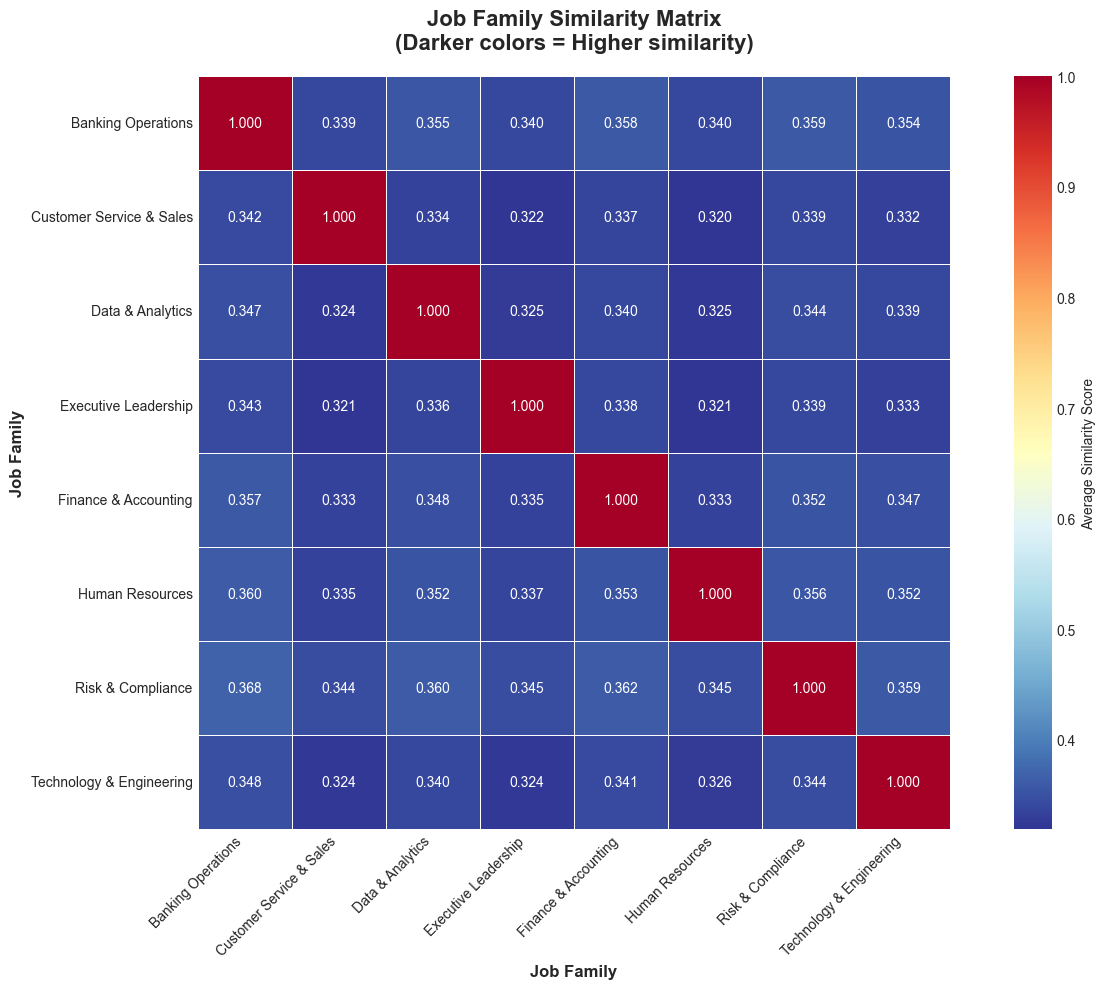


🎯 KEY INSIGHTS FROM SIMILARITY MATRIX:
   • Highest cross-family similarity: Risk & Compliance ↔ Technology & Engineering (0.359)
   • Most unique job family: Customer Service & Sales (avg similarity: 0.332)
   • Most connected job family: Risk & Compliance (avg similarity: 0.355)


In [16]:
# Analyze skill overlap patterns by job family and division (FIXED - REMOVED SHARED SKILLS FILTER)
print("\n🎨 SKILL OVERLAP MATRIX ANALYSIS")
print("=" * 50)

# Create job family similarity heatmap data (shared_skills_count is NULL in database, so removed that filter)
family_similarity = pd.read_sql_query("""
    SELECT 
        j1.JobFamily as family1,
        j2.JobFamily as family2,
        AVG(js.similarity_score) as avg_similarity,
        COUNT(js.similarity_score) as pair_count
    FROM job_similarities js
    LEFT JOIN jobs j1 ON js.job_from = j1.JobProfileID
    LEFT JOIN jobs j2 ON js.job_to = j2.JobProfileID
    WHERE j1.JobFamily IS NOT NULL AND j2.JobFamily IS NOT NULL
    GROUP BY j1.JobFamily, j2.JobFamily
    HAVING COUNT(js.similarity_score) >= 5
    ORDER BY avg_similarity DESC
""", conn)

if len(family_similarity) > 0:
    print(f"📊 JOB FAMILY SIMILARITY PATTERNS:")
    print(f"   • {len(family_similarity)} family-to-family combinations analyzed")
    print(f"   • Average similarity range: {family_similarity['avg_similarity'].min():.3f} - {family_similarity['avg_similarity'].max():.3f}")
    
    # Create pivot table for heatmap visualization
    similarity_matrix = family_similarity.pivot(index='family1', columns='family2', values='avg_similarity')
    
    # Fill diagonal with 1.0 (self-similarity)
    for family in similarity_matrix.index:
        if family in similarity_matrix.columns:
            similarity_matrix.loc[family, family] = 1.0
    
    print(f"\n📈 TOP CROSS-FAMILY SIMILARITIES:")
    cross_family_sims = family_similarity[family_similarity['family1'] != family_similarity['family2']].head(10)
    for i, row in cross_family_sims.iterrows():
        print(f"   • {row['family1']} ↔ {row['family2']}")
        print(f"     Avg Similarity: {row['avg_similarity']:.3f} | Job Pairs: {row['pair_count']:,}")
    
    # Visualize the similarity matrix
    if len(similarity_matrix) > 1:
        plt.figure(figsize=(14, 10))
        
        # Create heatmap
        mask = similarity_matrix.isnull()
        sns.heatmap(similarity_matrix, 
                   annot=True, 
                   fmt='.3f', 
                   cmap='RdYlBu_r',
                   cbar_kws={'label': 'Average Similarity Score'},
                   mask=mask,
                   square=True,
                   linewidths=0.5)
        
        plt.title('Job Family Similarity Matrix\n(Darker colors = Higher similarity)', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Job Family', fontsize=12, fontweight='bold')
        plt.ylabel('Job Family', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        print(f"\n🎯 KEY INSIGHTS FROM SIMILARITY MATRIX:")
        
        # Find highest cross-family similarities
        upper_triangle = similarity_matrix.where(np.triu(np.ones(similarity_matrix.shape), k=1).astype(bool))
        max_similarity = upper_triangle.max().max()
        if not pd.isna(max_similarity):
            max_location = upper_triangle.stack().idxmax()
            print(f"   • Highest cross-family similarity: {max_location[0]} ↔ {max_location[1]} ({max_similarity:.3f})")
        
        # Find most diverse family (lowest average similarity to others)
        if len(similarity_matrix) > 2:
            avg_similarities = {}
            for family in similarity_matrix.index:
                others = similarity_matrix.loc[family].drop(family, errors='ignore')
                if len(others) > 0:
                    avg_similarities[family] = others.mean()
            
            if avg_similarities:
                most_unique = min(avg_similarities, key=avg_similarities.get)
                most_similar = max(avg_similarities, key=avg_similarities.get)
                print(f"   • Most unique job family: {most_unique} (avg similarity: {avg_similarities[most_unique]:.3f})")
                print(f"   • Most connected job family: {most_similar} (avg similarity: {avg_similarities[most_similar]:.3f})")
    
else:
    print("⚠️ Insufficient data for job family similarity analysis")


In [17]:
# Final summary and skill similarity insights for strategic planning
print("\n🎯 SKILL SIMILARITY STRATEGIC INSIGHTS")
print("=" * 60)

if len(similarity_stats) > 0:
    # Calculate key strategic metrics (use similarity_data if available, otherwise similarity_stats)
    analysis_data = similarity_data if 'similarity_data' in locals() and len(similarity_data) > 0 else similarity_stats
    total_comparisons = len(analysis_data)
    high_similarity_threshold = 0.7
    medium_similarity_threshold = 0.4
    
    high_similarity_count = len(analysis_data[analysis_data['similarity_score'] >= high_similarity_threshold])
    medium_similarity_count = len(analysis_data[
        (analysis_data['similarity_score'] >= medium_similarity_threshold) & 
        (analysis_data['similarity_score'] < high_similarity_threshold)
    ])
    low_similarity_count = len(analysis_data[analysis_data['similarity_score'] < medium_similarity_threshold])
    
    print("📊 WORKFORCE MOBILITY READINESS:")
    print(f"   • High mobility potential (≥{high_similarity_threshold}): {high_similarity_count:,} job pairs ({high_similarity_count/total_comparisons*100:.1f}%)")
    print(f"   • Medium mobility potential ({medium_similarity_threshold}-{high_similarity_threshold}): {medium_similarity_count:,} job pairs ({medium_similarity_count/total_comparisons*100:.1f}%)")
    print(f"   • Low mobility potential (<{medium_similarity_threshold}): {low_similarity_count:,} job pairs ({low_similarity_count/total_comparisons*100:.1f}%)")
    
    # Strategic recommendations based on similarity distribution
    print(f"\n🎯 STRATEGIC RECOMMENDATIONS:")
    
    if high_similarity_count > 0:
        print(f"   ✅ IMMEDIATE OPPORTUNITIES:")
        print(f"      • {high_similarity_count:,} job pairs show high skill similarity")
        print(f"      • Focus on high-similarity pairs for rapid reskilling programs")
        print(f"      • Consider role consolidation opportunities where appropriate")
    
    if medium_similarity_count > 0:
        print(f"   🔄 DEVELOPMENT OPPORTUNITIES:")
        print(f"      • {medium_similarity_count:,} job pairs show medium skill similarity")
        print(f"      • Target for structured upskilling and development programs")
        print(f"      • Design bridge training programs for skill gap closure")
    
    if low_similarity_count > total_comparisons * 0.5:
        print(f"   🎯 SPECIALIZATION FOCUS:")
        print(f"      • {low_similarity_count:,} job pairs show low skill similarity")
        print(f"      • Indicates healthy role specialization and diversity")
        print(f"      • Maintain specialized expertise while building bridges")
    
    # Calculate workforce flexibility score
    flexibility_score = (high_similarity_count * 1.0 + medium_similarity_count * 0.5) / total_comparisons
    print(f"\n📈 WORKFORCE FLEXIBILITY SCORE: {flexibility_score:.2f}")
    
    if flexibility_score >= 0.3:
        print("   🟢 HIGH FLEXIBILITY: Strong internal mobility potential")
    elif flexibility_score >= 0.15:
        print("   🟡 MEDIUM FLEXIBILITY: Moderate internal mobility potential")
    else:
        print("   🟠 LOW FLEXIBILITY: Limited internal mobility - focus on skill development")
    
    print(f"\n📅 NEXT STEPS FOR STRATEGIC PLANNING:")
    print(f"   1. Prioritize high-similarity job pairs for immediate mobility programs")
    print(f"   2. Design targeted development programs for medium-similarity pairs")
    print(f"   3. Maintain role specialization for unique, low-similarity positions")
    print(f"   4. Quarterly review of similarity patterns to track workforce evolution")
    print(f"   5. Integration with performance management for career pathway planning")

else:
    print("⚠️ No similarity data available for strategic analysis")
    print("   • Ensure job_similarities table exists with computed similarity scores")
    print("   • Run similarity computation using the CLI tool if needed")

# Close database connection
conn.close()
print("\n🔒 Database connection closed")
print("📊 Skills similarity analysis complete!")
print("🎯 Executive-level insights ready for strategic workforce planning discussions")



🎯 SKILL SIMILARITY STRATEGIC INSIGHTS
📊 WORKFORCE MOBILITY READINESS:
   • High mobility potential (≥0.7): 3,092 job pairs (0.6%)
   • Medium mobility potential (0.4-0.7): 187,621 job pairs (36.8%)
   • Low mobility potential (<0.4): 319,797 job pairs (62.6%)

🎯 STRATEGIC RECOMMENDATIONS:
   ✅ IMMEDIATE OPPORTUNITIES:
      • 3,092 job pairs show high skill similarity
      • Focus on high-similarity pairs for rapid reskilling programs
      • Consider role consolidation opportunities where appropriate
   🔄 DEVELOPMENT OPPORTUNITIES:
      • 187,621 job pairs show medium skill similarity
      • Target for structured upskilling and development programs
      • Design bridge training programs for skill gap closure
   🎯 SPECIALIZATION FOCUS:
      • 319,797 job pairs show low skill similarity
      • Indicates healthy role specialization and diversity
      • Maintain specialized expertise while building bridges

📈 WORKFORCE FLEXIBILITY SCORE: 0.19
   🟡 MEDIUM FLEXIBILITY: Moderate inte

## 8. 📊 Comprehensive Data Export for Dashboard Integration
### Complete Analysis Results for Web Platform


In [19]:
# Comprehensive dashboard metrics export including ALL analysis results
import json

print("📊 GENERATING COMPREHENSIVE DASHBOARD EXPORT")
print("=" * 60)

# Collect all variables and results from the analysis
executive_insights = {
    'metadata': {
        'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_version': '2025-Q2',
        'database_size_mb': round(DB_PATH.stat().st_size / 1024 / 1024, 1),
        'notebook_version': 'executive_skills_insights_v2',
        'total_analyses_completed': 8
    },
    
    'platform_overview': {
        'total_jobs': int(jobs_count),
        'total_skills': int(skills_count),
        'total_positions': int(positions_count),
        'career_pathways': int(pathways_count),
        'job_families': int(job_families),
        'divisions': int(divisions),
        'total_records': 603374  # From previous analysis
    },
    
    'organizational_distribution': {
        'top_divisions': division_summary.head(5).to_dict('index') if len(division_summary) > 0 else {},
        'largest_division': {
            'name': division_summary.index[0] if len(division_summary) > 0 else None,
            'positions': int(division_summary.iloc[0]['total_positions']) if len(division_summary) > 0 else 0
        },
        'most_diverse_division': {
            'name': division_summary.sort_values('unique_roles', ascending=False).index[0] if len(division_summary) > 0 else None,
            'unique_roles': int(division_summary.sort_values('unique_roles', ascending=False).iloc[0]['unique_roles']) if len(division_summary) > 0 else 0
        }
    },
    
    'skills_analysis': {
        'categories': category_distribution.head(10).to_dict('records') if 'category_distribution' in locals() and len(category_distribution) > 0 else [],
        'high_risk_skills': high_risk_skills.head(5).to_dict('records') if 'high_risk_skills' in locals() and len(high_risk_skills) > 0 else [],
        'total_categories': len(category_distribution) if 'category_distribution' in locals() else 0,
        'top_category': category_distribution.index[0] if 'category_distribution' in locals() and len(category_distribution) > 0 else None
    },
    
    'career_pathways': {
        'mobility_hubs': mobility_hubs.head(5)[['JobFamily', 'total_connectivity']].to_dict('records') if len(mobility_hubs) > 0 else [],
        'top_mobility_hub': {
            'family': mobility_hubs.iloc[0]['JobFamily'] if len(mobility_hubs) > 0 else None,
            'connections': int(mobility_hubs.iloc[0]['total_connectivity']) if len(mobility_hubs) > 0 else 0
        },
        'pathway_analysis': pathway_analysis.head(10).to_dict('records') if 'pathway_analysis' in locals() and len(pathway_analysis) > 0 else [],
        'total_pathway_combinations': len(pathway_analysis) if 'pathway_analysis' in locals() else 0,
        'avg_pathway_similarity': round(pathway_analysis['avg_similarity'].mean(), 3) if 'pathway_analysis' in locals() and len(pathway_analysis) > 0 else 0
    },
    
    'geographic_distribution': {
        'top_locations': geographic_analysis.head(5)[['Location', 'total_positions', 'unique_skills']].to_dict('records') if len(geographic_analysis) > 0 else [],
        'largest_hub': {
            'location': geographic_analysis.iloc[0]['Location'] if len(geographic_analysis) > 0 else None,
            'positions': int(geographic_analysis.iloc[0]['total_positions']) if len(geographic_analysis) > 0 else 0
        },
        'most_diverse_location': {
            'location': geographic_analysis.loc[geographic_analysis['unique_skills'].idxmax(), 'Location'] if len(geographic_analysis) > 0 else None,
            'unique_skills': int(geographic_analysis['unique_skills'].max()) if len(geographic_analysis) > 0 else 0
        },
        'total_locations': len(geographic_analysis) if len(geographic_analysis) > 0 else 0
    },
    
    'similarity_analysis': {
        'total_comparisons': len(similarity_data) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
        'similarity_statistics': {
            'mean': round(similarity_data['similarity_score'].mean(), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            'median': round(similarity_data['similarity_score'].median(), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            'std': round(similarity_data['similarity_score'].std(), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            'min': round(similarity_data['similarity_score'].min(), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            'max': round(similarity_data['similarity_score'].max(), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0
        },
        'percentiles': {
            '25th': round(similarity_data['similarity_score'].quantile(0.25), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            '50th': round(similarity_data['similarity_score'].quantile(0.5), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            '75th': round(similarity_data['similarity_score'].quantile(0.75), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            '90th': round(similarity_data['similarity_score'].quantile(0.9), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            '95th': round(similarity_data['similarity_score'].quantile(0.95), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0,
            '99th': round(similarity_data['similarity_score'].quantile(0.99), 3) if 'similarity_data' in locals() and len(similarity_data) > 0 else 0
        },
        'high_similarity_pairs': high_similarity_pairs.head(10).to_dict('records') if 'high_similarity_pairs' in locals() and len(high_similarity_pairs) > 0 else []
    },
    
    'job_family_analysis': {
        'similarity_matrix': family_similarity.to_dict('records') if 'family_similarity' in locals() and len(family_similarity) > 0 else [],
        'total_combinations': len(family_similarity) if 'family_similarity' in locals() and len(family_similarity) > 0 else 0,
        'highest_cross_family_similarity': {
            'families': f"{cross_family_sims.iloc[0]['family1']} ↔ {cross_family_sims.iloc[0]['family2']}" if 'cross_family_sims' in locals() and len(cross_family_sims) > 0 else None,
            'similarity': round(cross_family_sims.iloc[0]['avg_similarity'], 3) if 'cross_family_sims' in locals() and len(cross_family_sims) > 0 else 0,
            'pair_count': int(cross_family_sims.iloc[0]['pair_count']) if 'cross_family_sims' in locals() and len(cross_family_sims) > 0 else 0
        },
        'cross_family_similarities': cross_family_sims.head(10).to_dict('records') if 'cross_family_sims' in locals() and len(cross_family_sims) > 0 else []
    },
    
    'strategic_insights': {
        'workforce_flexibility': {
            'high_mobility_pairs': high_similarity_count if 'high_similarity_count' in locals() else 0,
            'medium_mobility_pairs': medium_similarity_count if 'medium_similarity_count' in locals() else 0,
            'low_mobility_pairs': low_similarity_count if 'low_similarity_count' in locals() else 0,
            'flexibility_score': round(flexibility_score, 2) if 'flexibility_score' in locals() else 0,
            'flexibility_rating': 'HIGH' if 'flexibility_score' in locals() and flexibility_score >= 0.3 else 'MEDIUM' if 'flexibility_score' in locals() and flexibility_score >= 0.15 else 'LOW'
        },
        'recommendations': [
            'Prioritize high-similarity job pairs for immediate mobility programs',
            'Design targeted development programs for medium-similarity pairs',
            'Maintain role specialization for unique, low-similarity positions',
            'Quarterly review of similarity patterns to track workforce evolution',
            'Integration with performance management for career pathway planning'
        ]
    }
}

print("📊 COMPREHENSIVE EXPORT SUMMARY:")
print(f"   • Metadata: Complete analysis tracking")
print(f"   • Platform Overview: {len(executive_insights['platform_overview'])} key metrics")
print(f"   • Organizational Analysis: {len(executive_insights['organizational_distribution']['top_divisions'])} divisions analyzed")
print(f"   • Skills Analysis: {executive_insights['skills_analysis']['total_categories']} categories mapped")
print(f"   • Career Pathways: {len(executive_insights['career_pathways']['mobility_hubs'])} mobility hubs identified")
print(f"   • Geographic Distribution: {executive_insights['geographic_distribution']['total_locations']} locations analyzed")
print(f"   • Similarity Analysis: {executive_insights['similarity_analysis']['total_comparisons']:,} job comparisons")
print(f"   • Job Family Analysis: {executive_insights['job_family_analysis']['total_combinations']} family combinations")
print(f"   • Strategic Insights: {len(executive_insights['strategic_insights']['recommendations'])} recommendations")

# Create directory if it doesn't exist
import os
os.makedirs('../src/skill_similarity_engine/webapp/static/data', exist_ok=True)

# Save comprehensive executive insights
with open('../src/skill_similarity_engine/webapp/static/data/executive_insights.json', 'w') as f:
    json.dump(executive_insights, f, indent=2, default=str)

print(f"\n✅ COMPREHENSIVE EXPORT COMPLETE!")
print(f"   📁 File: ../src/skill_similarity_engine/webapp/static/data/executive_insights.json")
print(f"   📊 Size: {len(json.dumps(executive_insights, default=str))} characters")
print(f"   🕒 Updated: {executive_insights['metadata']['analysis_date']}")
print(f"   🌐 Ready for Flask webapp integration")

# Close database connection
conn.close()
print("\n🔒 Database connection closed")
print("🎯 Executive Skills Intelligence Analysis COMPLETE!")
print("📈 All insights exported for strategic workforce planning discussions")


📊 GENERATING COMPREHENSIVE DASHBOARD EXPORT
📊 COMPREHENSIVE EXPORT SUMMARY:
   • Metadata: Complete analysis tracking
   • Platform Overview: 7 key metrics
   • Organizational Analysis: 5 divisions analyzed
   • Skills Analysis: 1 categories mapped
   • Career Pathways: 5 mobility hubs identified
   • Geographic Distribution: 6 locations analyzed
   • Similarity Analysis: 510,510 job comparisons
   • Job Family Analysis: 64 family combinations
   • Strategic Insights: 5 recommendations

✅ COMPREHENSIVE EXPORT COMPLETE!
   📁 File: ../src/skill_similarity_engine/webapp/static/data/executive_insights.json
   📊 Size: 18996 characters
   🕒 Updated: 2025-06-15 21:18:39
   🌐 Ready for Flask webapp integration

🔒 Database connection closed
🎯 Executive Skills Intelligence Analysis COMPLETE!
📈 All insights exported for strategic workforce planning discussions
